# Attestation timings within committee - missed slots

#### Maria Silva, July 2025


## 1. Imports

In [33]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [34]:
# Main directories and files
current_path = os.getcwd()
repo_dir = os.path.abspath(os.path.join(current_path, ".."))
data_path = "missed_slots_13169495_13198195"

In [35]:
# plotting theme
sns.set_theme(
    style="whitegrid", palette="Set2", rc={"figure.dpi": 500, "axes.titlesize": 15}
)

## 2. Load data

#### Attestations

In [36]:
missed_atts_file = os.path.join(repo_dir, "data", data_path, "sample_atts.parquet")
atts_df = pd.read_parquet(missed_atts_file)
atts_df["atts_prop_time_ms"] = atts_df["atts_arrival_time_ms"]-4000
atts_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3088686 entries, 0 to 3088685
Data columns (total 8 columns):
 #   Column                Dtype 
---  ------                ----- 
 0   slot                  int64 
 1   node_name             object
 2   node_country          object
 3   atts_validator        int64 
 4   atts_subnet           object
 5   remote_peer_id        int64 
 6   atts_arrival_time_ms  int64 
 7   atts_prop_time_ms     int64 
dtypes: int64(5), object(3)
memory usage: 188.5+ MB


#### Validator info

In [37]:
val_file = os.path.join(repo_dir, "data", "ethseer_val_info.parquet")
val_df = pd.read_parquet(val_file)
val_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2073612 entries, 0 to 2073611
Data columns (total 2 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   index   int64 
 1   entity  object
dtypes: int64(1), object(1)
memory usage: 31.6+ MB


#### Client Versions

In [38]:
client_versions_file = os.path.join(repo_dir, "data", data_path, "client_versions.parquet")
client_versions_df = pd.read_parquet(client_versions_file)
client_versions_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3599410 entries, 0 to 3599409
Data columns (total 12 columns):
 #   Column                       Dtype         
---  ------                       -----         
 0   node_name                    object        
 1   node_country                 object        
 2   node_client_version          object        
 3   node_client_implementation   object        
 4   node_client_id               object        
 5   remote_agent_implementation  object        
 6   remote_agent_version         object        
 7   remote_agent_version_major   object        
 8   remote_agent_version_minor   object        
 9   remote_agent_version_patch   object        
 10  event_date_time              datetime64[ns]
 11  remote_peer_id               int64         
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 329.5+ MB


#### Join data and process

In [39]:
# Join
df = (
    atts_df.merge(val_df, right_on="index", left_on="atts_validator", how="left")
    .drop(columns=["index"])
    .fillna({"entity": "unknown"})
)
# Group low cardinality entities into "other" category
entity_counts = df["entity"].value_counts()/len(df)
df = df.merge(entity_counts, left_on="entity", right_index=True)
df["entity"] = np.where(df["count"]>0.01, df["entity"], "other")
# Print info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3088686 entries, 0 to 3088685
Data columns (total 10 columns):
 #   Column                Dtype  
---  ------                -----  
 0   slot                  int64  
 1   node_name             object 
 2   node_country          object 
 3   atts_validator        int64  
 4   atts_subnet           object 
 5   remote_peer_id        int64  
 6   atts_arrival_time_ms  int64  
 7   atts_prop_time_ms     int64  
 8   entity                object 
 9   count                 float64
dtypes: float64(1), int64(5), object(4)
memory usage: 235.6+ MB


In [40]:
df["slot"].nunique()

268

In [41]:
df["node_name"].sort_values().unique()

array(['ethpandaops/mainnet/xatu-tysm-ams3-mainnet-003-subnets-0-1',
       'ethpandaops/mainnet/xatu-tysm-ams3-mainnet-004-subnets-0-1',
       'ethpandaops/mainnet/xatu-tysm-ams3-mainnet-005-subnets-0-1',
       'ethpandaops/mainnet/xatu-tysm-blr1-mainnet-003-subnets-0-1',
       'ethpandaops/mainnet/xatu-tysm-blr1-mainnet-004-subnets-0-1',
       'ethpandaops/mainnet/xatu-tysm-blr1-mainnet-005-subnets-0-1',
       'ethpandaops/mainnet/xatu-tysm-sfo3-mainnet-003-subnets-0-1',
       'ethpandaops/mainnet/xatu-tysm-sfo3-mainnet-004-subnets-0-1',
       'ethpandaops/mainnet/xatu-tysm-sfo3-mainnet-005-subnets-0-1',
       'ethpandaops/mainnet/xatu-tysm-syd1-mainnet-003-subnets-0-1',
       'ethpandaops/mainnet/xatu-tysm-syd1-mainnet-004-subnets-0-1',
       'ethpandaops/mainnet/xatu-tysm-syd1-mainnet-005-subnets-0-1'],
      dtype=object)

In [42]:
# Join client versions with attestations data on remote_peer_id
# Check data sizes before merge to understand potential performance issues
print(f"Attestations data shape: {atts_df.shape}")
print(f"Client versions data shape: {client_versions_df.shape}")
print(f"Unique remote_peer_ids in attestations: {atts_df['remote_peer_id'].nunique()}")
print(f"Unique remote_peer_ids in client versions: {client_versions_df['remote_peer_id'].nunique()}")

# Use a more efficient merge approach - first check for common peer IDs
common_peer_ids = set(atts_df['remote_peer_id'].unique()) & set(client_versions_df['remote_peer_id'].unique())
print(f"Common peer IDs: {len(common_peer_ids)}")

# Filter client versions to only include relevant peer IDs to reduce merge size
relevant_client_versions = client_versions_df[
    client_versions_df['remote_peer_id'].isin(atts_df['remote_peer_id'].unique())
].copy()
print(f"Filtered client versions shape: {relevant_client_versions.shape}")


# df_with_clients = df.merge(
#     client_versions_df, 
#     left_on="remote_peer_id", 
#     right_on="remote_peer_id", 
#     how="left"
# )
# df_with_clients.info()


Attestations data shape: (3088686, 8)
Client versions data shape: (3599410, 12)
Unique remote_peer_ids in attestations: 1750
Unique remote_peer_ids in client versions: 20285
Common peer IDs: 1748
Filtered client versions shape: (791257, 12)


## 3. Overall distribution

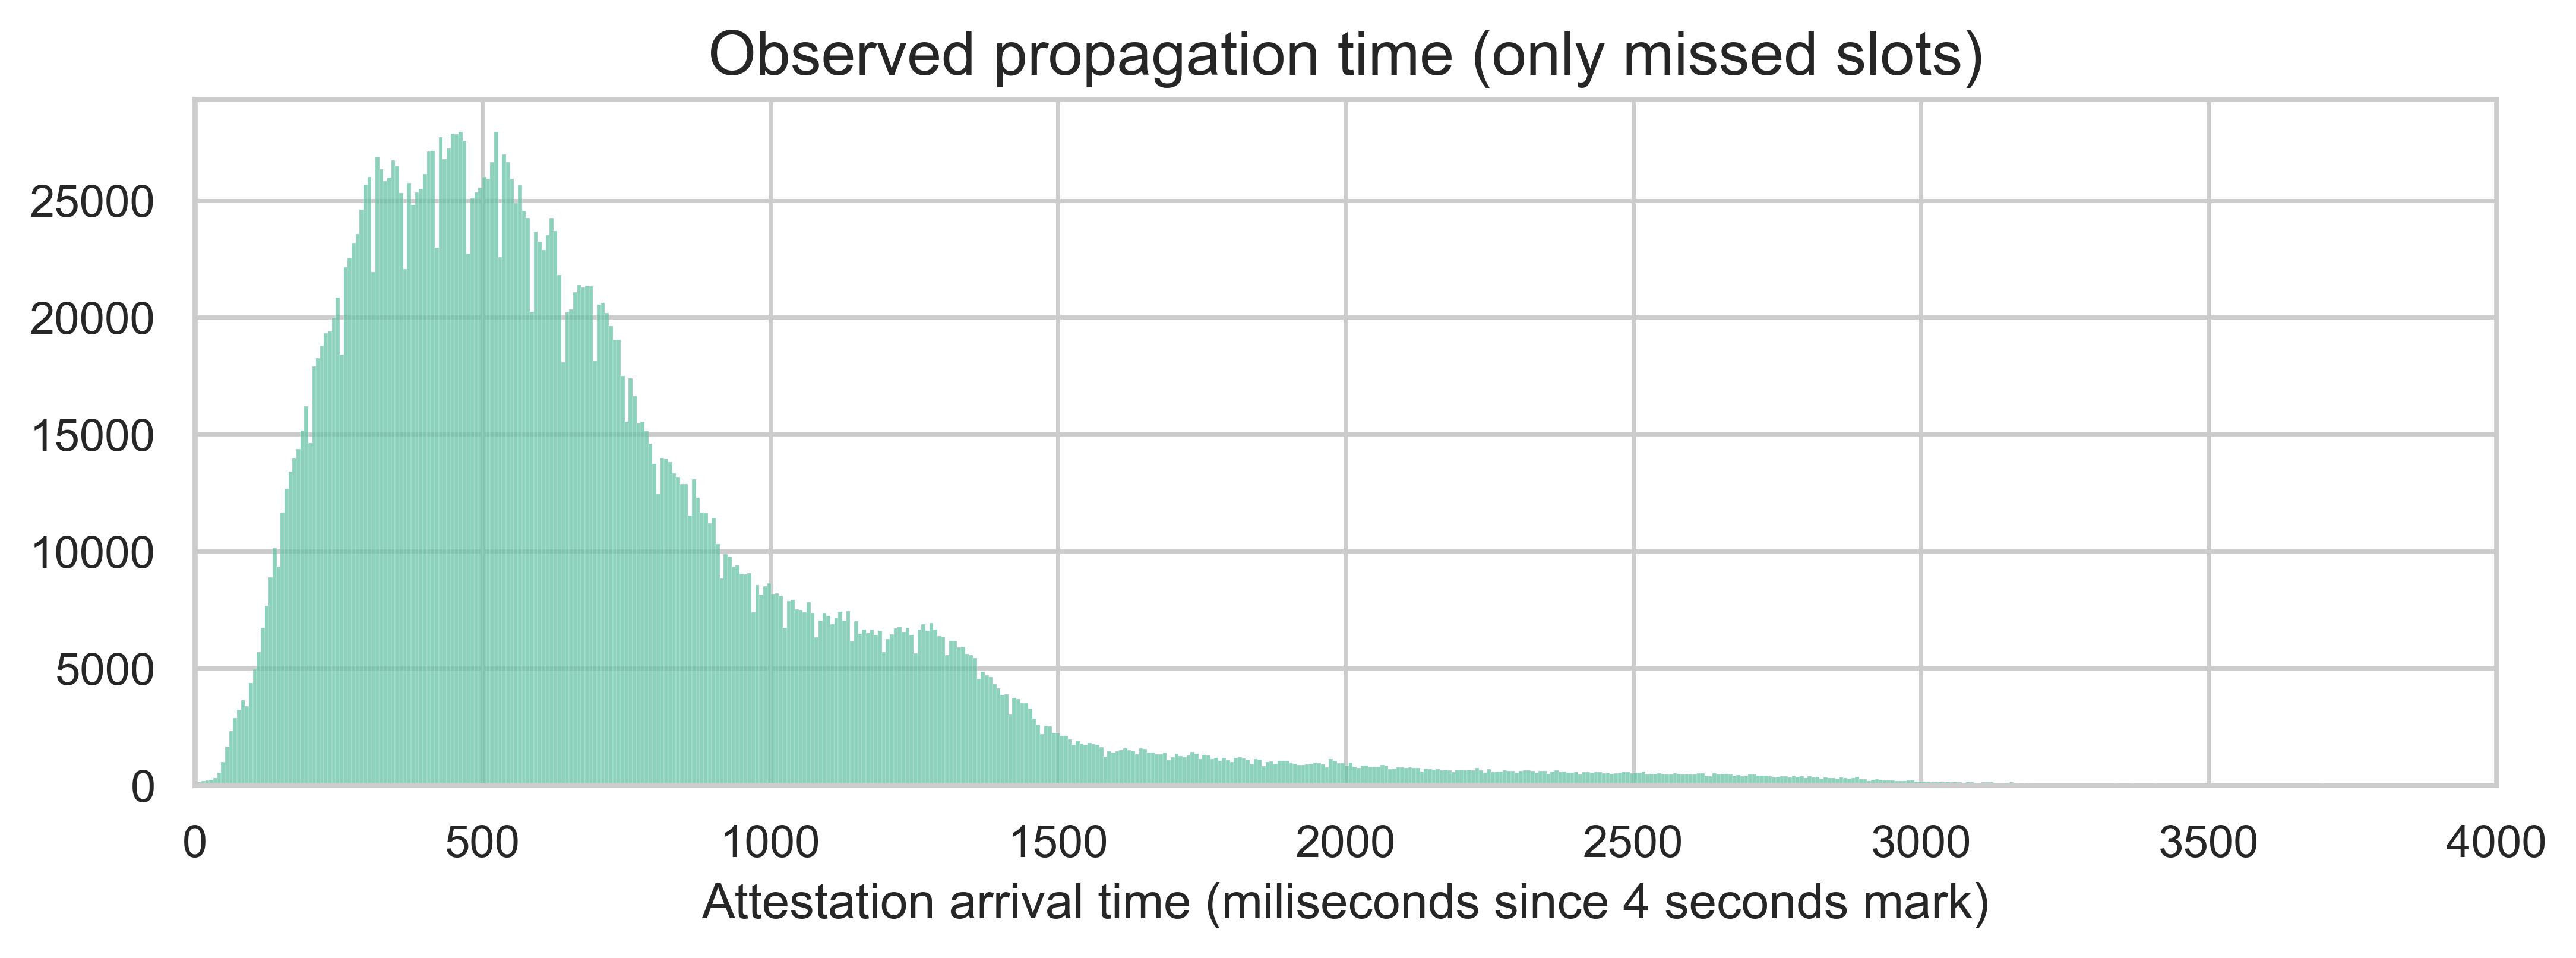

In [43]:
plt.figure(figsize=(10, 3))
sns.histplot(data=df, x="atts_prop_time_ms")
plt.xlim(0, 4000)
plt.title("Observed propagation time (only missed slots)")
plt.ylabel("")
plt.xlabel("Attestation arrival time (miliseconds since 4 seconds mark)")
plt.show()

In [44]:
df["atts_prop_time_ms"].agg(["mean", "std"])

mean    704.979069
std     502.087757
Name: atts_prop_time_ms, dtype: float64

In [45]:
df["atts_prop_time_ms"].quantile([0.25, 0.5, 0.66, 0.75, 0.95, 0.99])

0.25     377.0
0.50     583.0
0.66     744.0
0.75     878.0
0.95    1595.0
0.99    2616.0
Name: atts_prop_time_ms, dtype: float64

#### Per beacon node

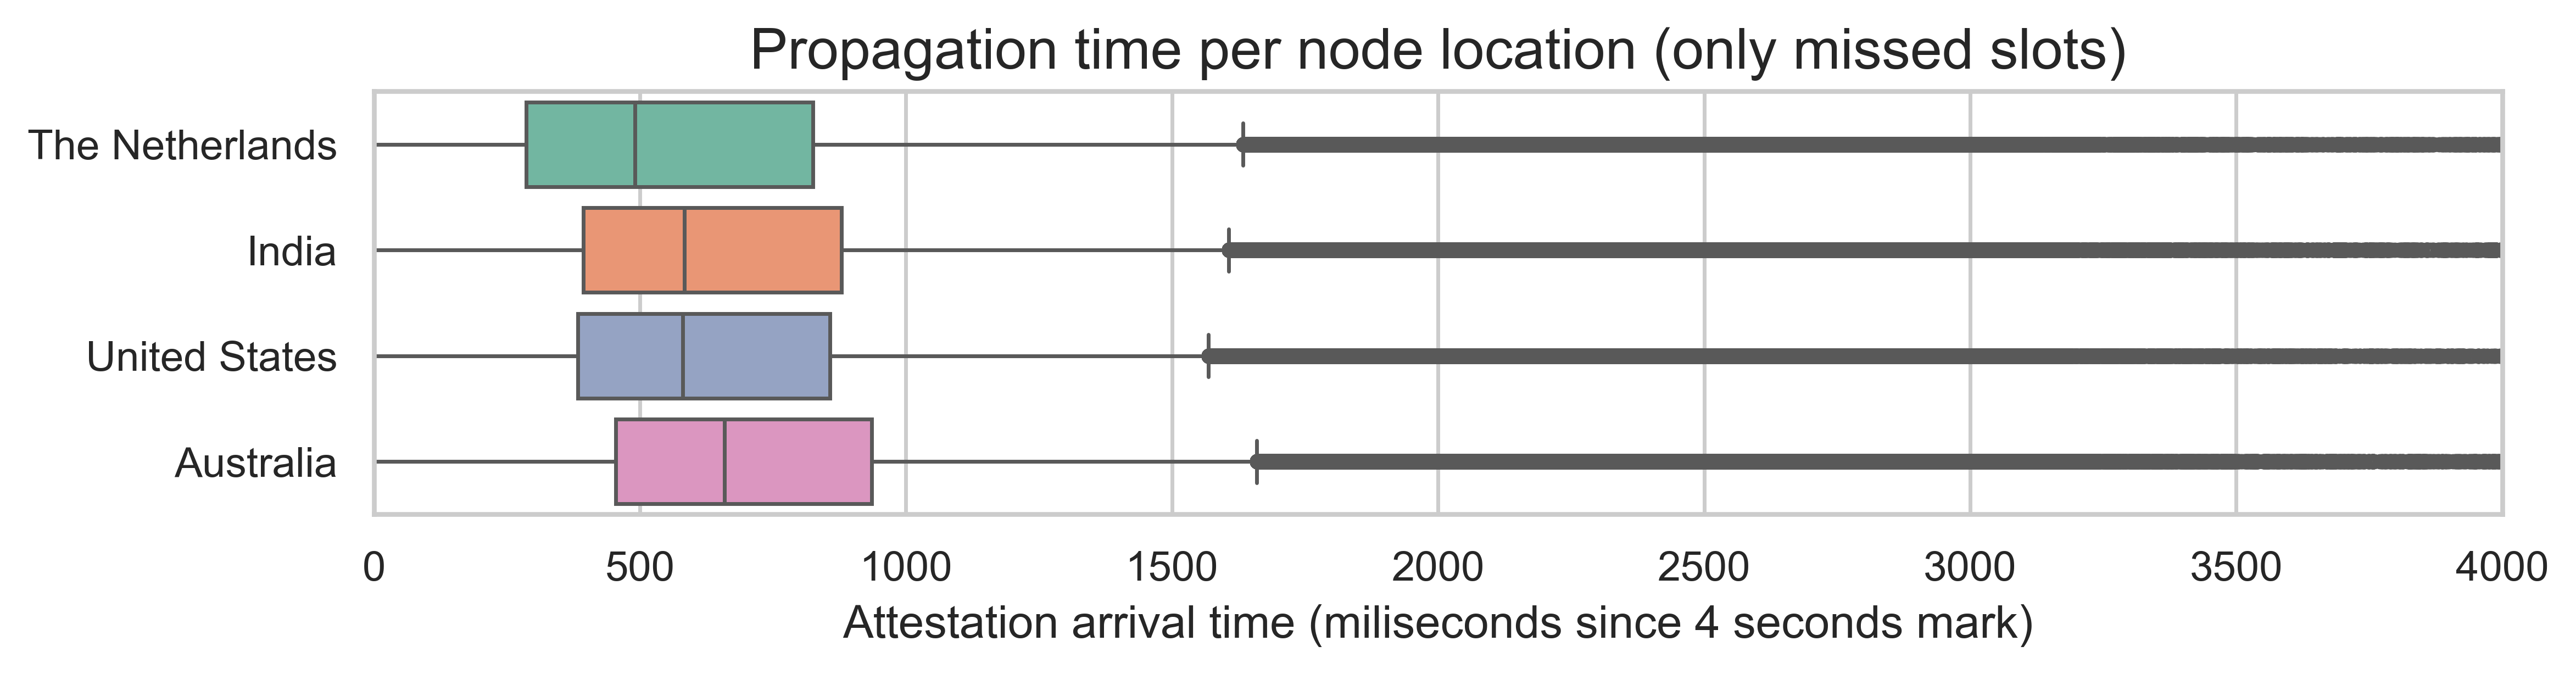

In [46]:
plt.figure(figsize=(10, 2))
sns.boxplot(
    data=df.sort_values("node_name"),
    x="atts_prop_time_ms",
    y="node_country",
    hue="node_country",
    legend=False,
    fliersize=3
)
plt.xlim(0,4000)
plt.title("Propagation time per node location (only missed slots)")
plt.ylabel("")
plt.xlabel("Attestation arrival time (miliseconds since 4 seconds mark)")
plt.show()

In [47]:
df.groupby("node_country")["atts_prop_time_ms"].quantile(0.66)

node_country
Australia          814.0
India              739.0
The Netherlands    671.0
United States      729.0
Name: atts_prop_time_ms, dtype: float64

In [48]:
df.groupby("node_country")["atts_prop_time_ms"].quantile(0.95)

node_country
Australia          1581.0
India              1603.0
The Netherlands    1590.0
United States      1607.0
Name: atts_prop_time_ms, dtype: float64

#### Per attester entity

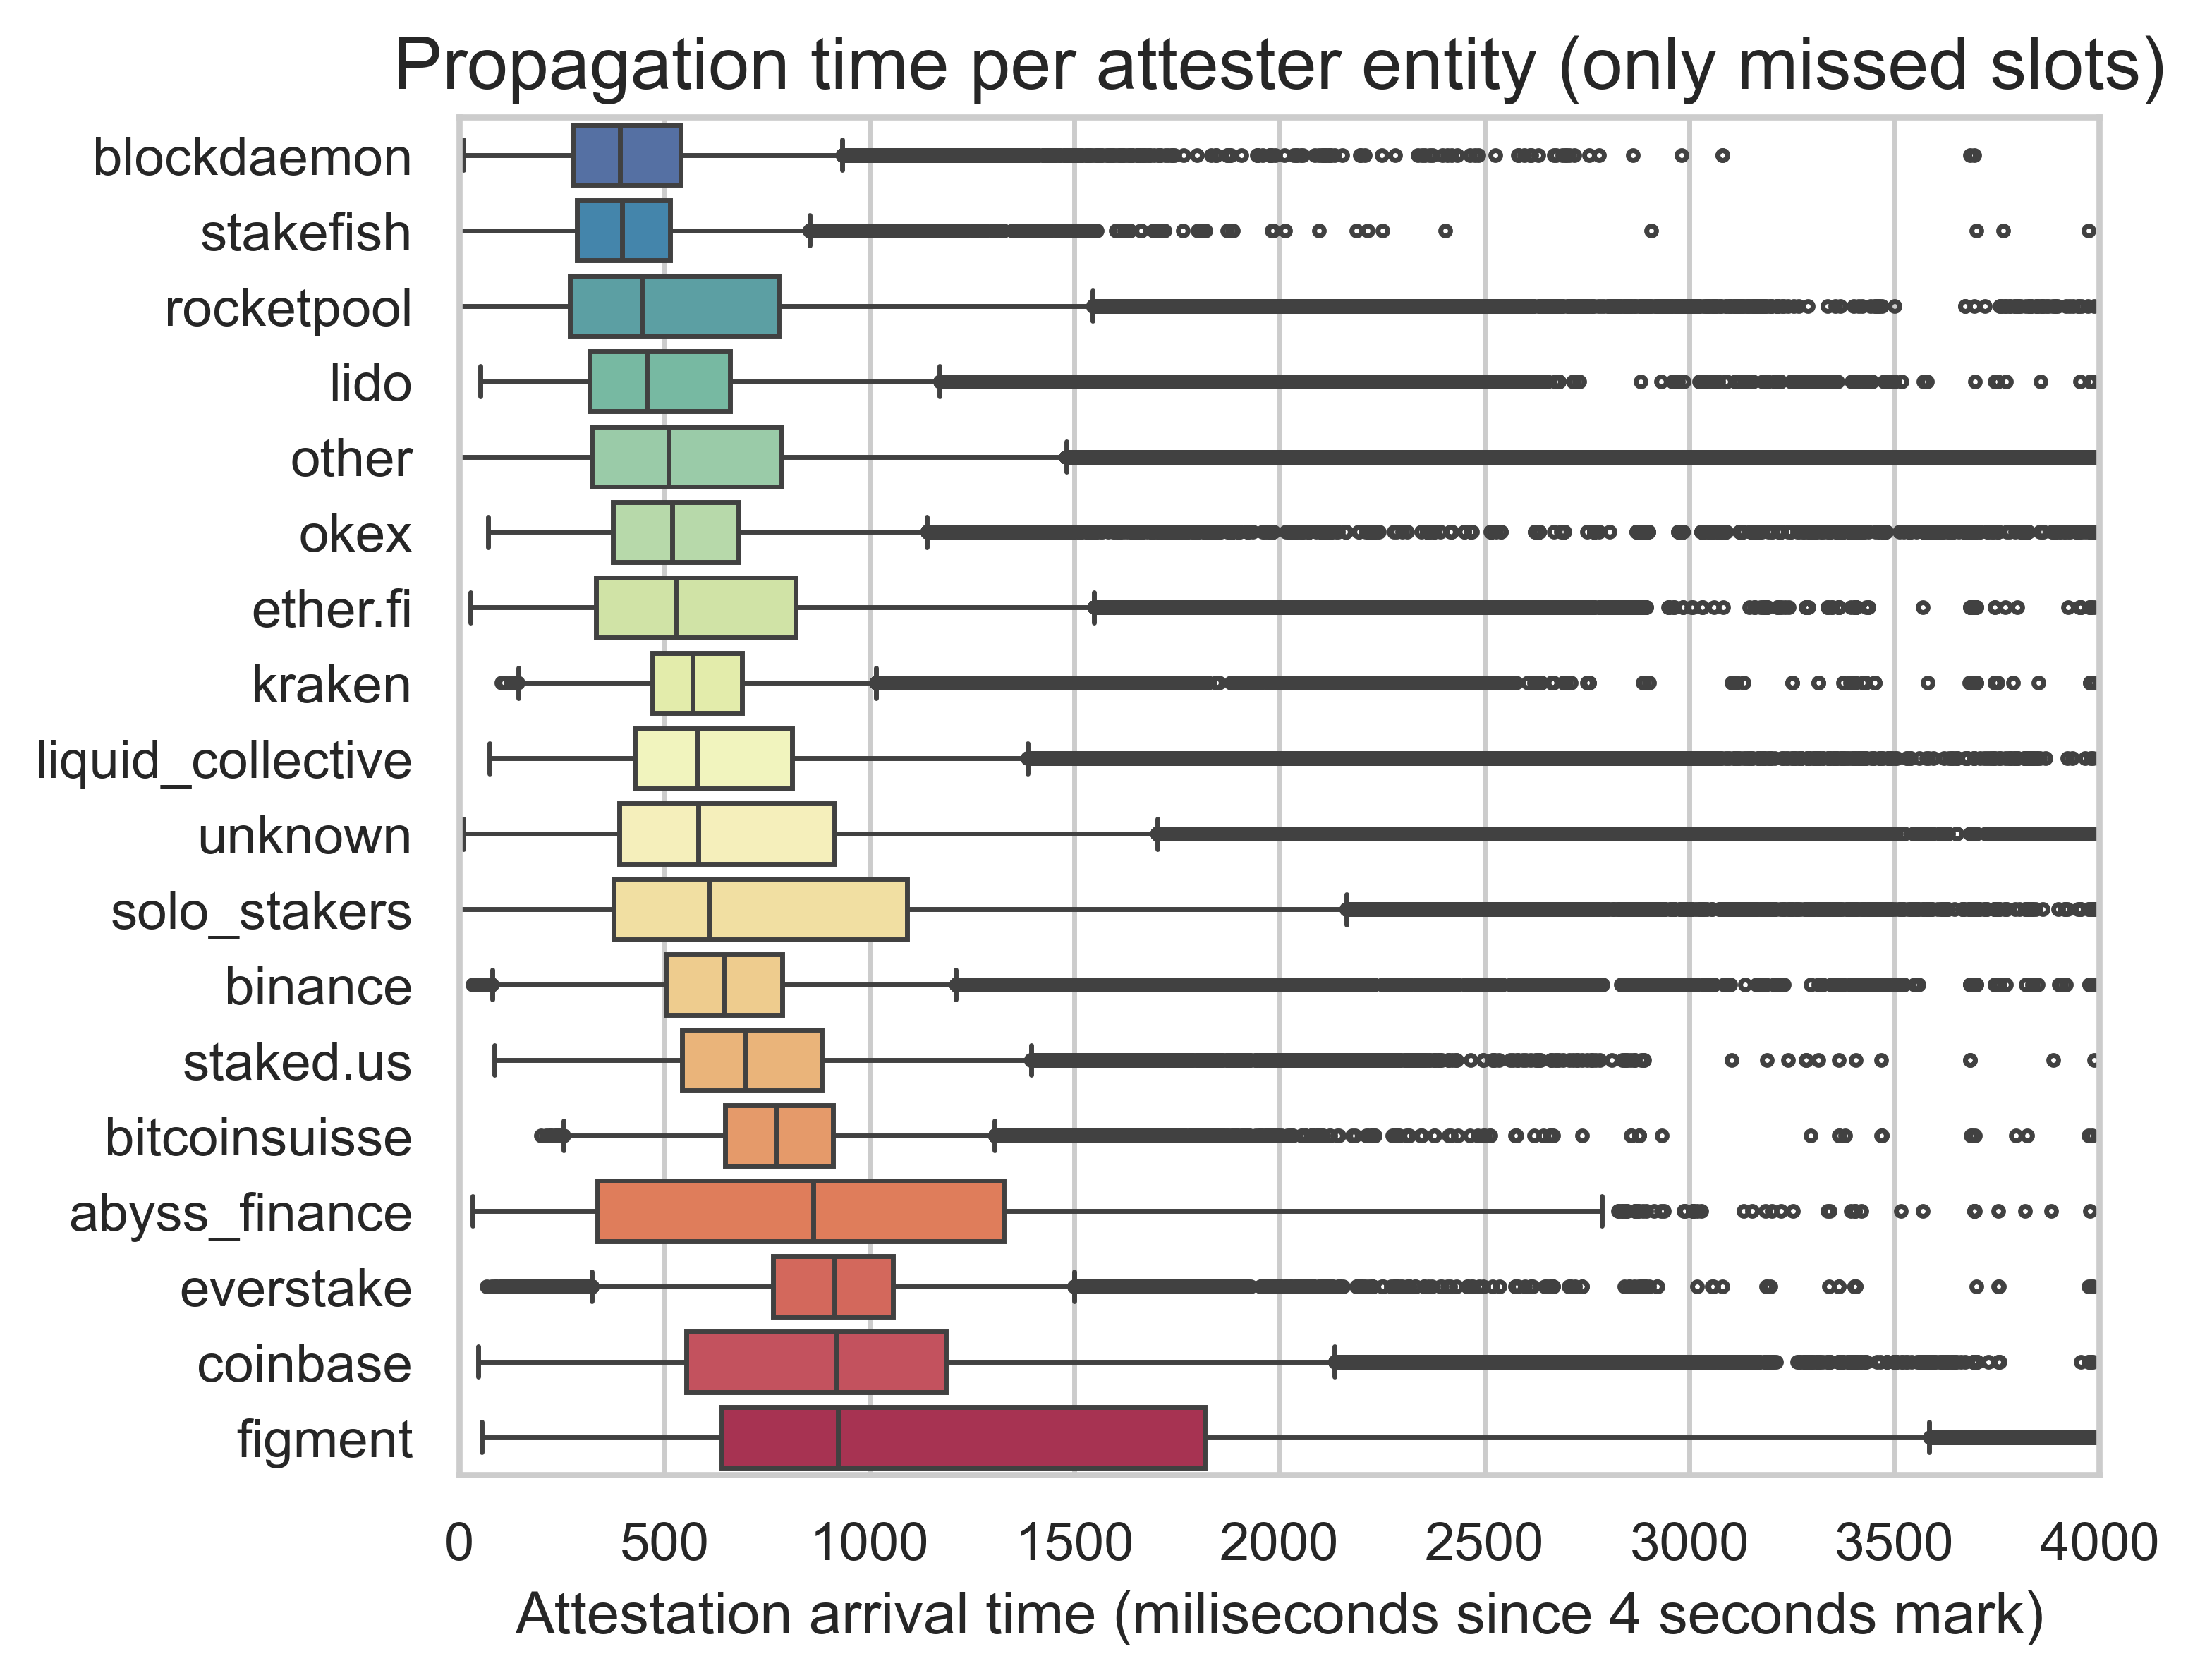

In [49]:
median_df = (
    df.groupby("entity")["atts_prop_time_ms"]
    .median()
    .reset_index()
    .rename(columns={"atts_prop_time_ms": "median"})
)
temp_df = df.merge(median_df, on="entity", how="left").sort_values("median")

plt.figure(figsize=(6, 5))
sns.boxplot(
    data=temp_df,
    x="atts_prop_time_ms",
    y="entity",
    hue="entity",
    legend=False,
    palette="Spectral_r",
    fliersize=2
)
plt.xlim(0,4000)
plt.title("Propagation time per attester entity (only missed slots)")
plt.ylabel("")
plt.xlabel("Attestation arrival time (miliseconds since 4 seconds mark)")
plt.show()

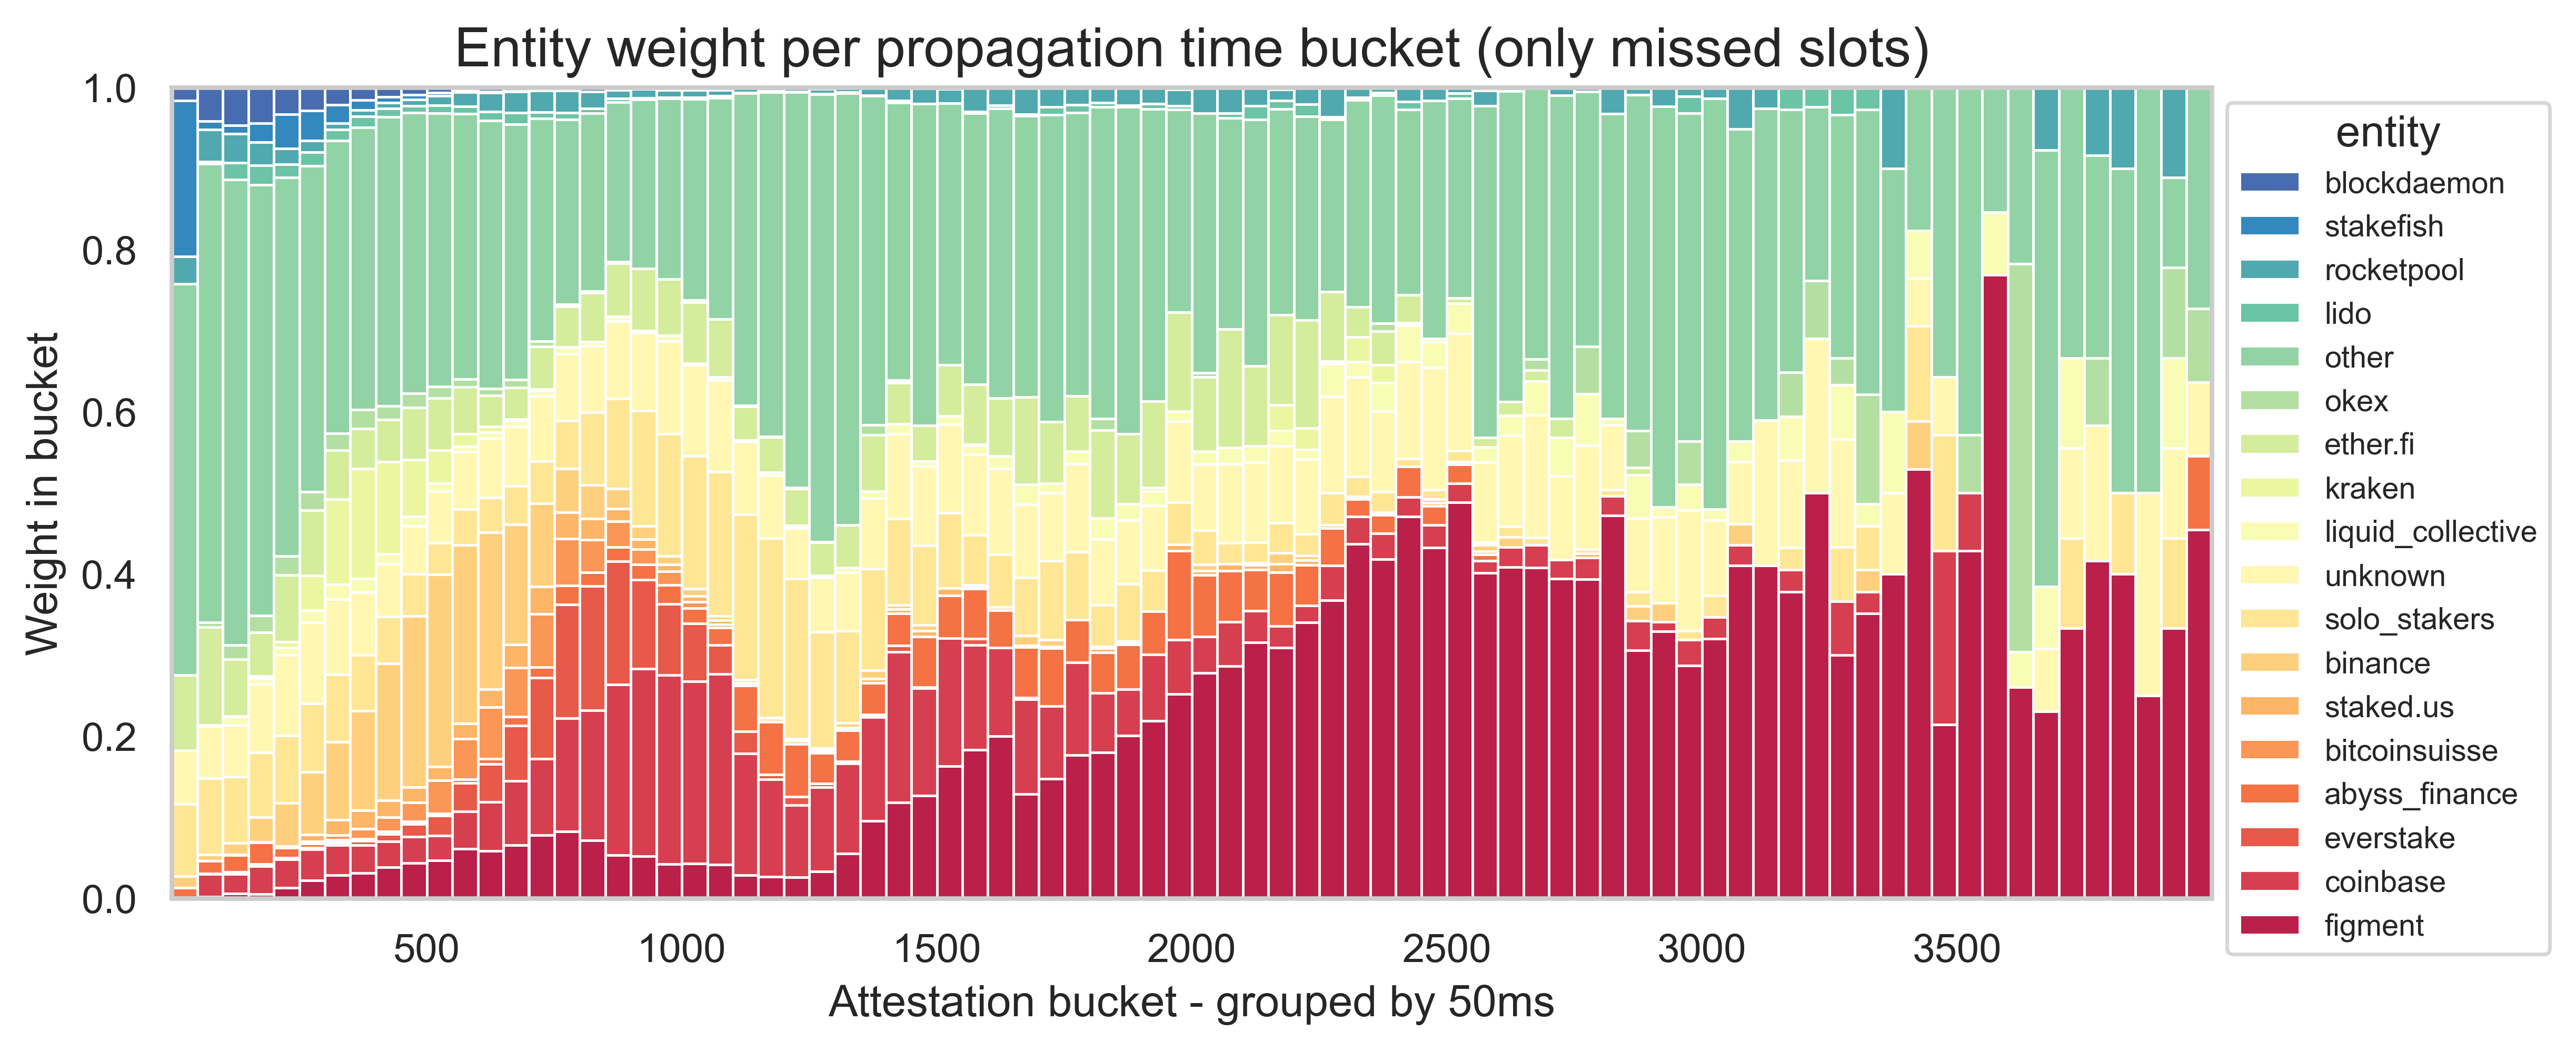

In [50]:
temp_df = (
    df[df["atts_prop_time_ms"] > 0]
    .groupby(["slot", "atts_subnet", "atts_validator", "entity"])["atts_prop_time_ms"]
    .min()
    .reset_index()
    .merge(median_df, on="entity", how="left")
    .sort_values("median")
)
temp_df = temp_df[temp_df["atts_prop_time_ms"].between(0,4000)]
plt.figure(figsize=(10, 4))
ax = sns.histplot(
    data=temp_df,
    x="atts_prop_time_ms",
    hue="entity",
    multiple="fill",
    palette="Spectral_r",
    alpha=1,
    bins=80
)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), fontsize='x-small')
plt.title("Entity weight per propagation time bucket (only missed slots)")
plt.ylabel("Weight in bucket")
plt.xlabel("Attestation bucket - grouped by 50ms")
plt.show()

#### Attestation Propgation by Client

Original client_versions_df shape: (3599410, 12)
Deduplicated shape: (20285, 4)
Merged df shape: (3088686, 11)

Attestation propagation statistics by client implementation:
  remote_agent_implementation    count        mean  median         std
0                      erigon    21924  619.736408   481.0  451.868520
2                    lodestar    18567  657.897345   568.0  381.430717
3                      nimbus     4952  660.604200   577.5  486.276587
7                     unknown  2854914  704.178619   581.0  501.267520
4                       prysm   114499  719.045319   583.0  539.306753
1                  lighthouse    16194  740.063727   606.0  487.689508
6                        tysm    32062  820.353846   712.0  461.848356
5                        teku     1147  931.896251   837.0  655.296047


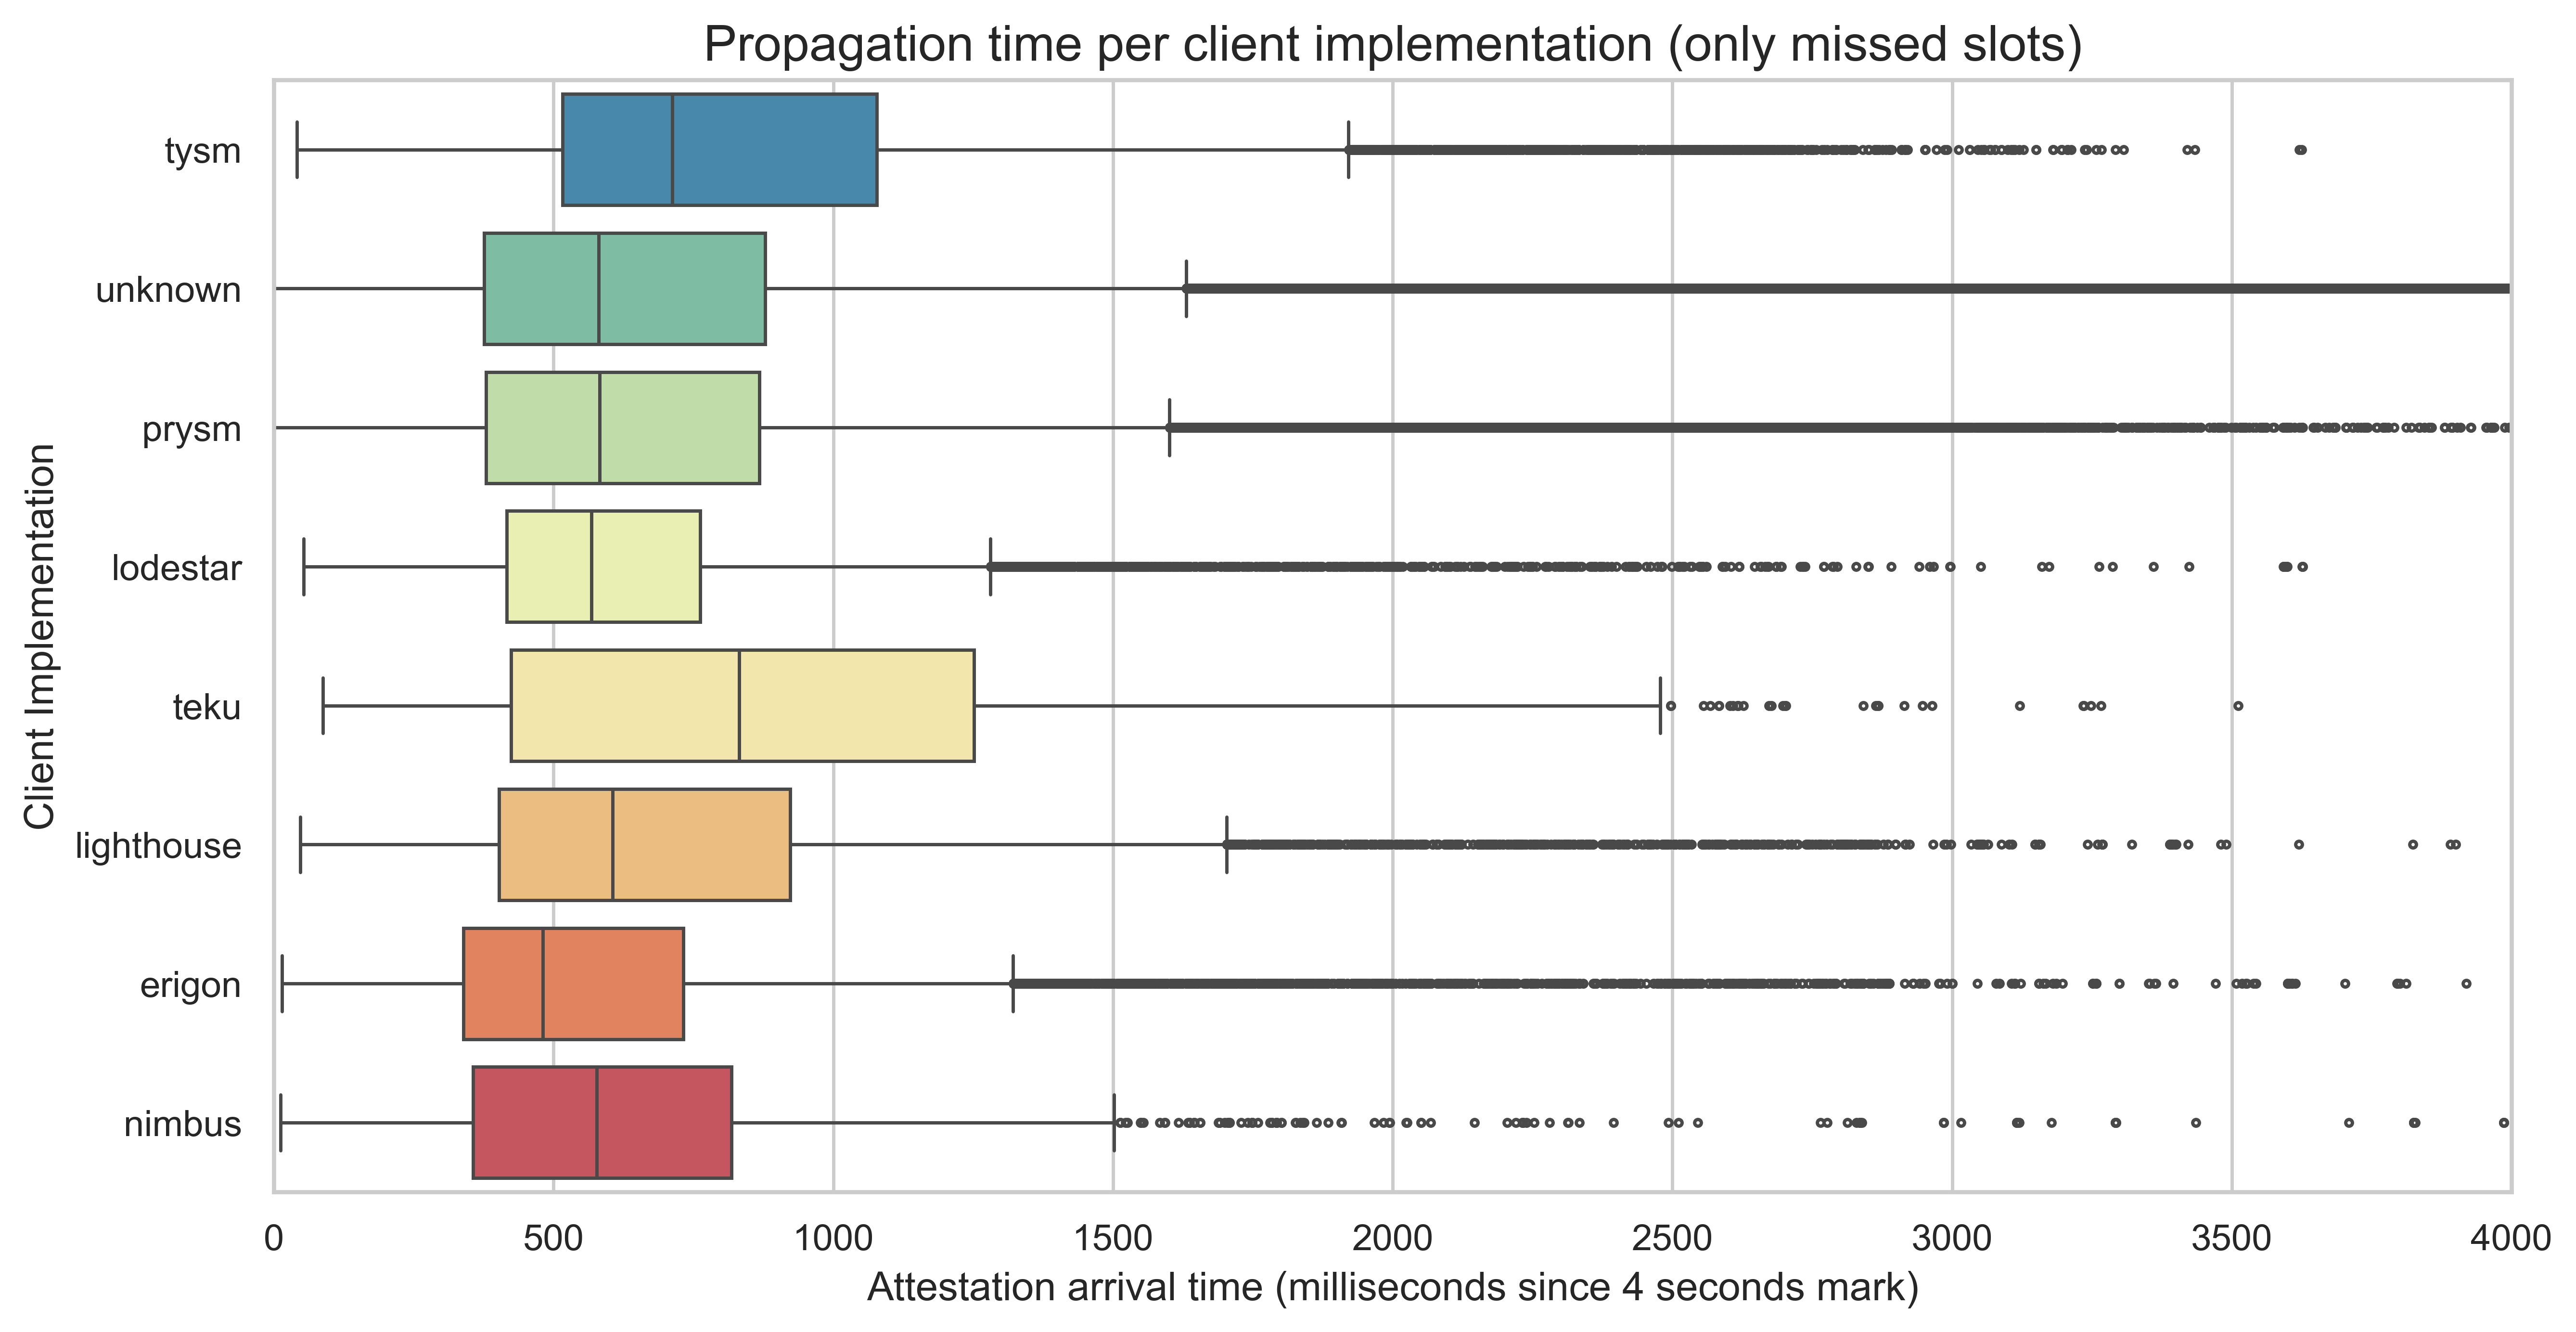


Percentiles by client implementation:
   remote_agent_implementation  Percentile  atts_prop_time_ms
0                       erigon        0.66             620.00
1                       erigon        0.95            1410.55
2                   lighthouse        0.66             789.00
3                   lighthouse        0.95            1694.00
4                     lodestar        0.66             693.00
5                     lodestar        0.95            1374.00
6                       nimbus        0.66             713.00
7                       nimbus        0.95            1369.00
8                        prysm        0.66             741.00
9                        prysm        0.95            1684.00
10                        teku        0.66             986.00
11                        teku        0.95            2198.00
12                        tysm        0.66             883.00
13                        tysm        0.95            1674.00
14                     unknown 

In [51]:
# Map attestations to client versions using remote_peer_id
# IMPORTANT: client_versions_df has multiple rows per remote_peer_id (time series data)
# We need to deduplicate to ONE row per peer to avoid Cartesian product explosion

# Deduplicate: keep the most recent client version for each remote_peer_id
client_versions_dedup = (
    client_versions_df
    .sort_values('event_date_time', ascending=False)
    .drop_duplicates(subset=['remote_peer_id'], keep='first')
    [['remote_peer_id', 'remote_agent_implementation', 'remote_agent_version', 'remote_agent_version_major']]
)
print(f"Original client_versions_df shape: {client_versions_df.shape}")
print(f"Deduplicated shape: {client_versions_dedup.shape}")

# Now merge - this will be fast since we have 1:1 mapping on remote_peer_id
df_with_client = atts_df.merge(client_versions_dedup, on='remote_peer_id', how='left')
print(f"Merged df shape: {df_with_client.shape}")

# Group by client implementation and calculate statistics
client_stats = (
    df_with_client[df_with_client["atts_prop_time_ms"] > 0]
    .groupby("remote_agent_implementation")["atts_prop_time_ms"]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
    .sort_values("median")
)

print("\nAttestation propagation statistics by client implementation:")
print(client_stats)

# Create visualization of propagation times by client implementation
temp_df = df_with_client[df_with_client["atts_prop_time_ms"].between(0, 4000)]
temp_df = temp_df.dropna(subset=['remote_agent_implementation'])

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=temp_df,
    x="atts_prop_time_ms",
    y="remote_agent_implementation",
    palette="Spectral_r",
    fliersize=2
)
plt.xlim(0, 4000)
plt.title("Propagation time per client implementation (only missed slots)")
plt.ylabel("Client Implementation")
plt.xlabel("Attestation arrival time (milliseconds since 4 seconds mark)")
plt.show()

# Show percentiles by client implementation
client_percentiles = (
    df_with_client[df_with_client["atts_prop_time_ms"] > 0]
    .groupby("remote_agent_implementation")["atts_prop_time_ms"]
    .quantile([0.66, 0.95])
    .reset_index()
    .rename(columns={"level_1": "Percentile"})
)
print("\nPercentiles by client implementation:")
print(client_percentiles)


#### Min across nodes

In [52]:
min_df = df.groupby(["slot", "atts_validator"])["atts_prop_time_ms"].min().reset_index()

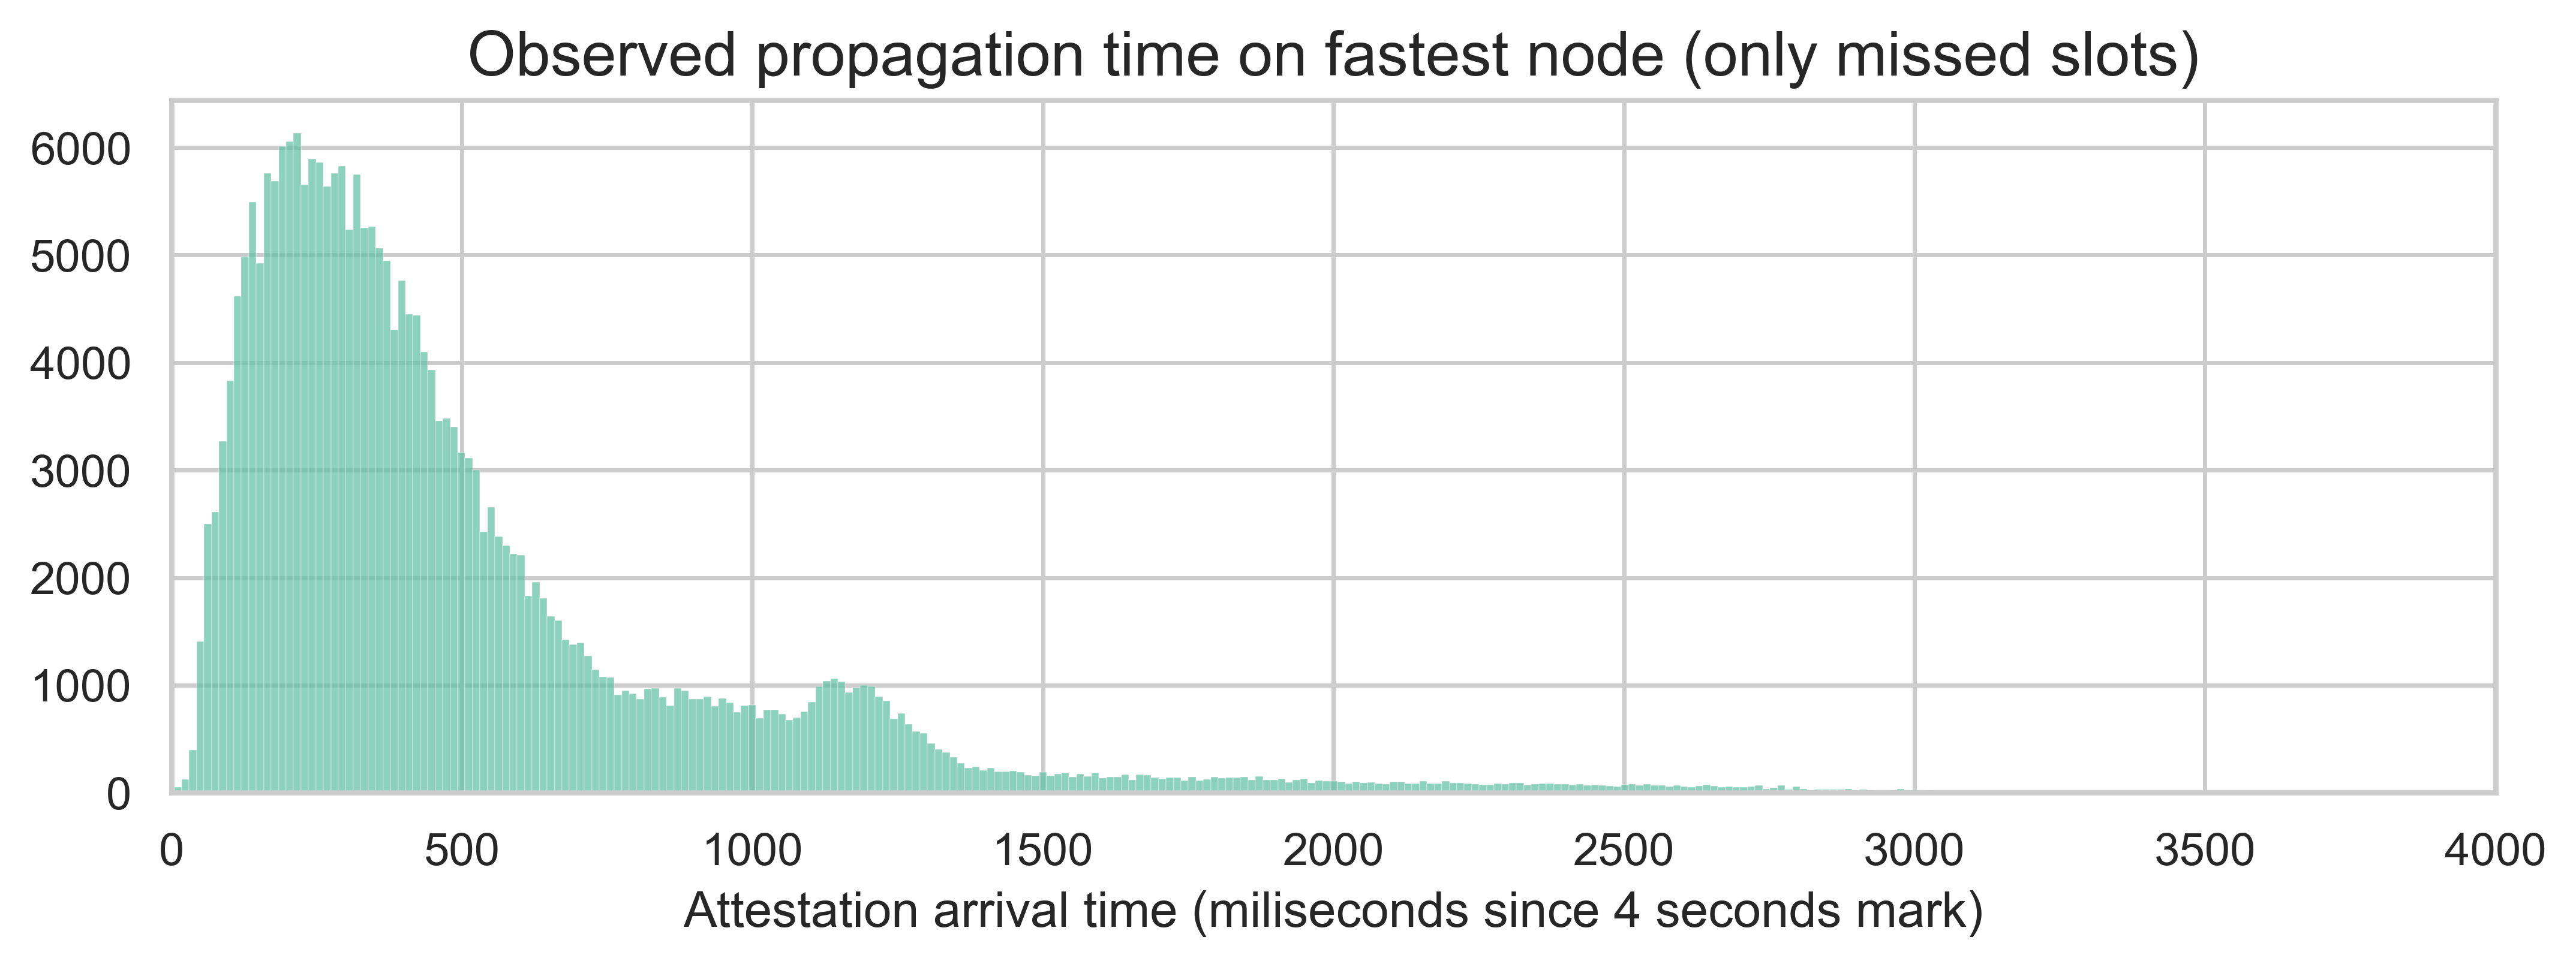

In [53]:
plt.figure(figsize=(10, 3))
sns.histplot(data=min_df, x="atts_prop_time_ms")
plt.xlim(0, 4000)
plt.title("Observed propagation time on fastest node (only missed slots)")
plt.ylabel("")
plt.xlabel("Attestation arrival time (miliseconds since 4 seconds mark)")
plt.show()

In [54]:
min_df["atts_prop_time_ms"].agg(["mean", "std"])

mean    525.285544
std     486.630869
Name: atts_prop_time_ms, dtype: float64

In [55]:
min_df["atts_prop_time_ms"].quantile([0.25, 0.5, 0.66, 0.75, 0.95, 0.99])

0.25     224.00
0.50     374.00
0.66     509.00
0.75     633.00
0.95    1386.95
0.99    2485.00
Name: atts_prop_time_ms, dtype: float64

## 4. Distribution on subnet

In [56]:
agg_df = (
    df[df["atts_prop_time_ms"] > 0]
    .groupby(["slot", "atts_subnet", "atts_validator", "entity"])["atts_prop_time_ms"]
    .min()
    .reset_index()
    .groupby(["slot", "atts_subnet"])["atts_prop_time_ms"]
    .quantile([0.66, 0.95])
    .reset_index()
    .rename(columns={"level_2": "Percentile"})
)

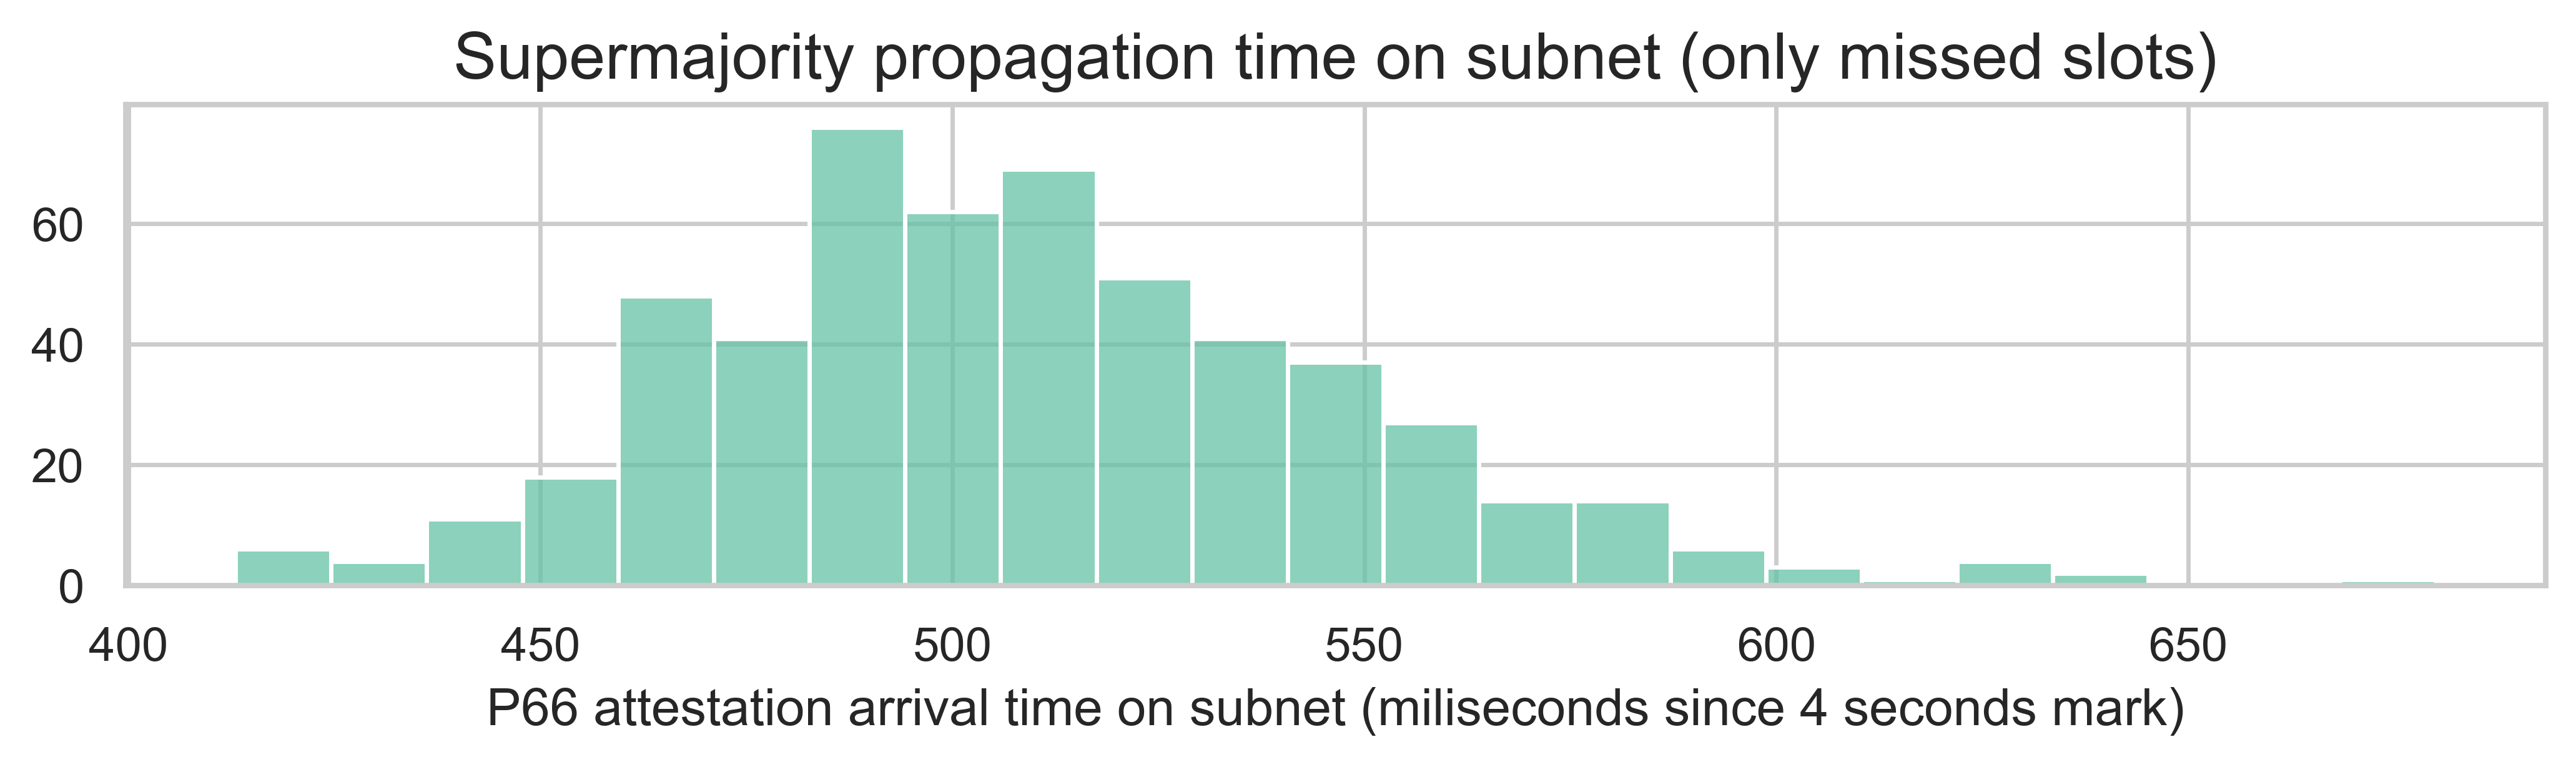

In [57]:
plt.figure(figsize=(10, 2))
sns.histplot(data=agg_df[agg_df["Percentile"]==0.66], x="atts_prop_time_ms")
plt.title("Supermajority propagation time on subnet (only missed slots)")
plt.ylabel("")
plt.xlabel("P66 attestation arrival time on subnet (miliseconds since 4 seconds mark)")
plt.show()

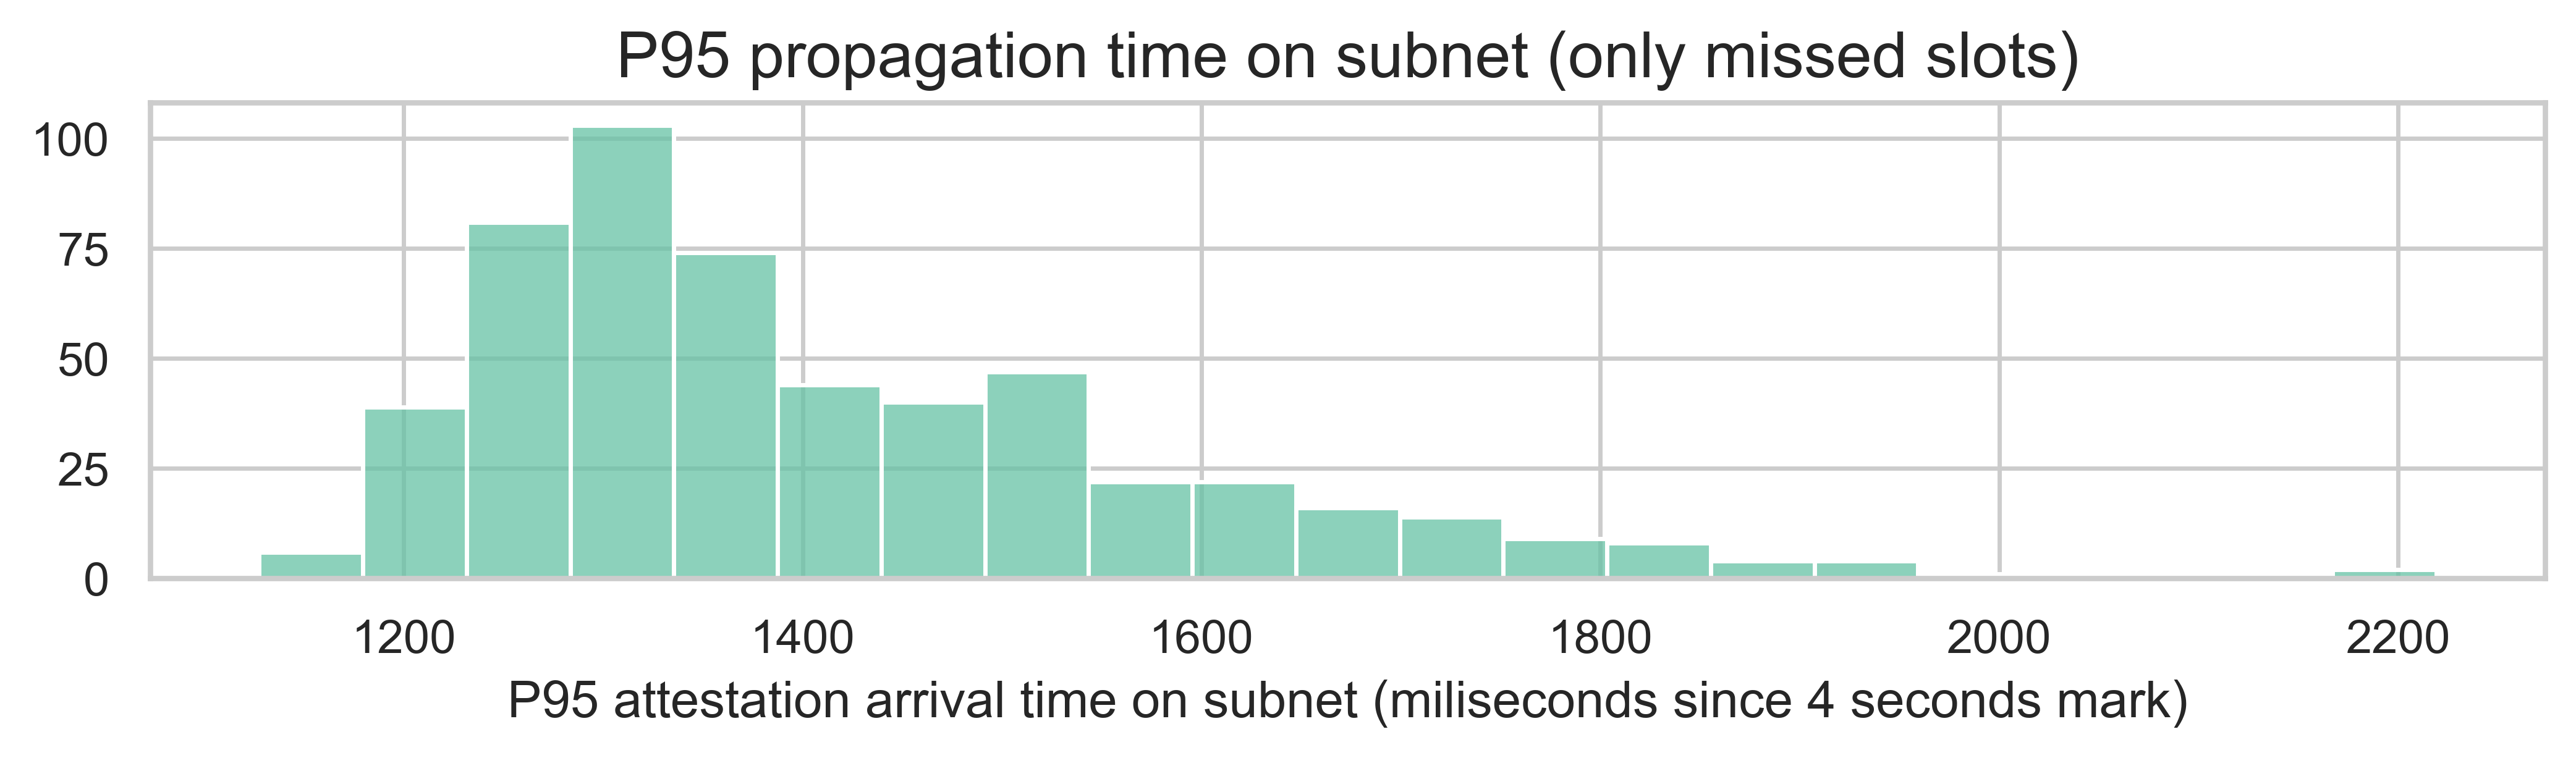

In [58]:
plt.figure(figsize=(10, 2))
sns.histplot(data=agg_df[agg_df["Percentile"]==0.95], x="atts_prop_time_ms")
plt.title("P95 propagation time on subnet (only missed slots)")
plt.ylabel("")
plt.xlabel("P95 attestation arrival time on subnet (miliseconds since 4 seconds mark)")
plt.show()

In [59]:
agg_df.groupby("Percentile")["atts_prop_time_ms"].quantile(0.95)

Percentile
0.66     577.585
0.95    1763.850
Name: atts_prop_time_ms, dtype: float64

In [60]:
agg_df.groupby("Percentile")["atts_prop_time_ms"].max()

Percentile
0.66     680.0
0.95    2219.1
Name: atts_prop_time_ms, dtype: float64

In [61]:
agg_df.groupby("Percentile")["atts_prop_time_ms"].mean()

Percentile
0.66     509.262724
0.95    1412.487966
Name: atts_prop_time_ms, dtype: float64

## 5. Example CDFs

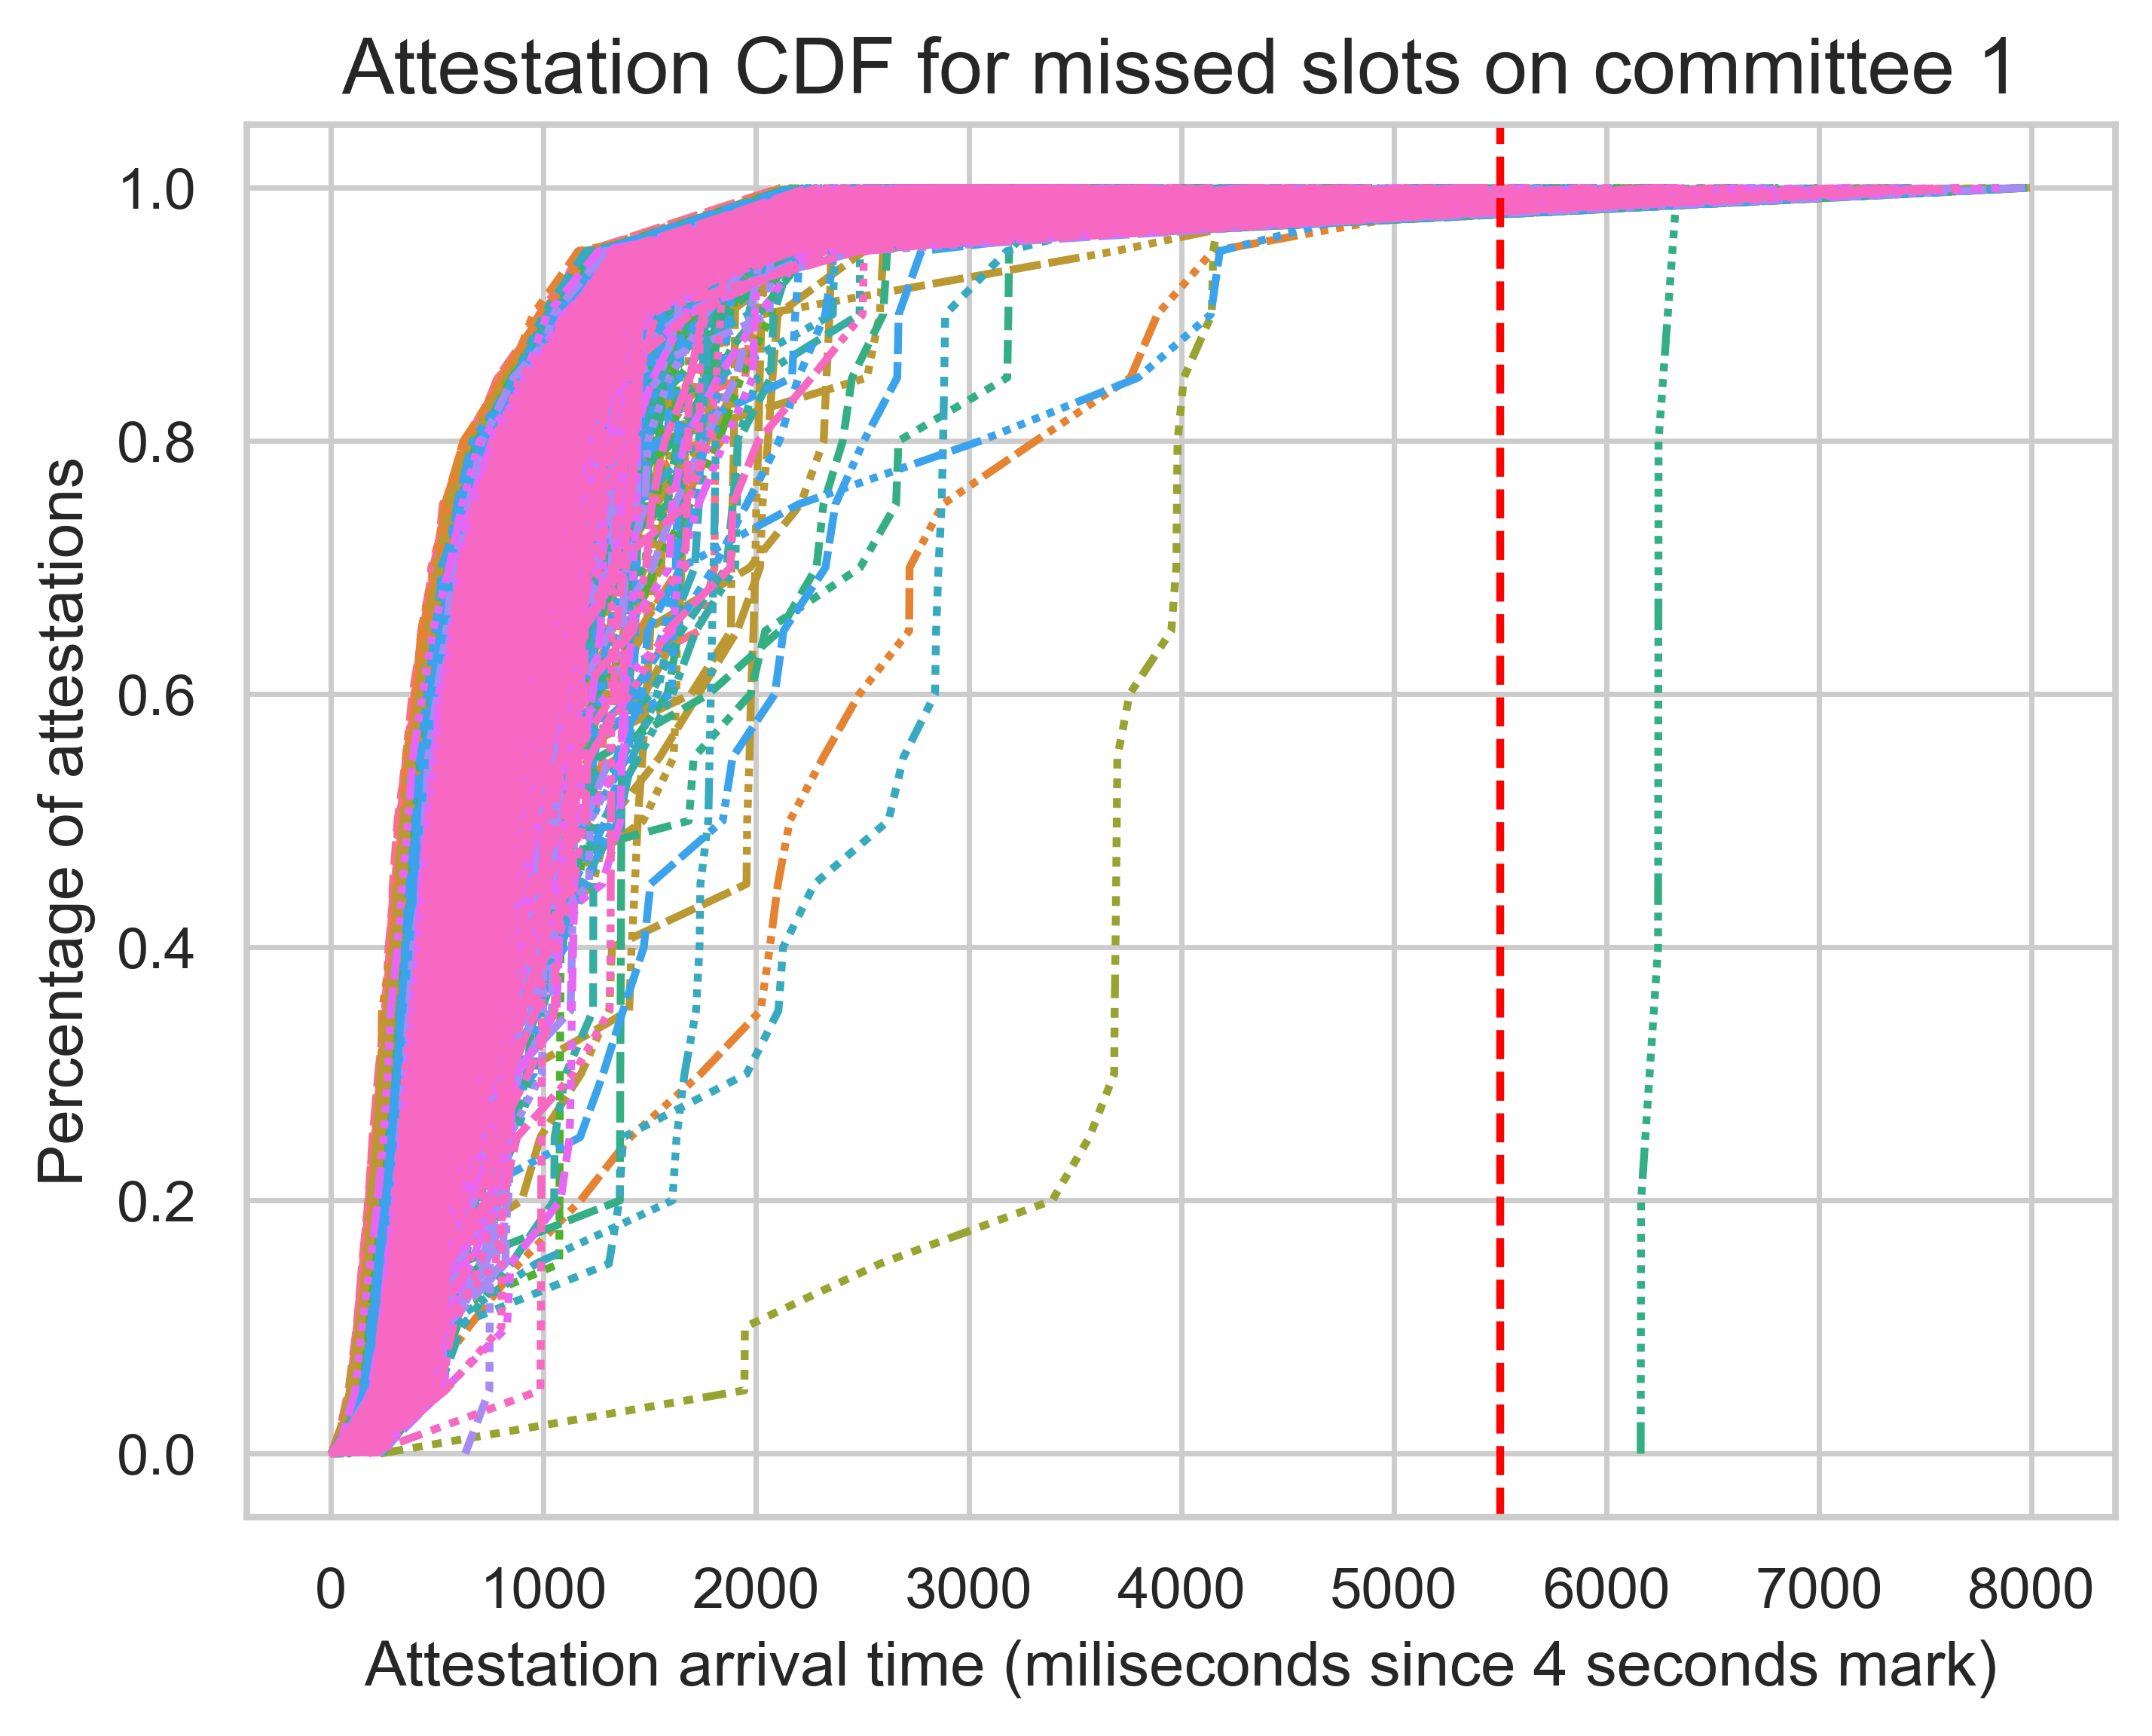

In [62]:
temp_df = df[(df["atts_prop_time_ms"] > 0) & (atts_df["atts_subnet"] == "1")].copy()
temp_df = (
    temp_df.groupby(["node_name", "slot"])["atts_prop_time_ms"]
    .quantile(np.arange(0, 1.05, 0.05))
    .reset_index()
)
temp_df.columns = ["node_name", "slot", "percentile", "attes_time"]

ax = sns.lineplot(
    temp_df,
    x="attes_time",
    y="percentile",
    hue="node_name",
    style="slot",
    errorbar=None,
    legend=False,
)
plt.axvline(x=5500, color="red", linestyle="dashed")
plt.title("Attestation CDF for missed slots on committee 1")
plt.xlabel("Attestation arrival time (miliseconds since 4 seconds mark)")
plt.ylabel("Percentage of attestations")
plt.show()

In [63]:
temp_df.groupby("percentile")["attes_time"].mean().head(25)

percentile
0.00      92.165730
0.05     221.717587
0.10     275.654963
0.15     318.644679
0.20     360.725531
0.25     406.145209
0.30     448.369320
0.35     486.488702
0.40     523.937828
0.45     559.846879
0.50     596.536673
0.55     636.854120
0.60     681.704744
0.65     726.173159
0.70     777.003402
0.75     838.947253
0.80     933.577715
0.85    1087.751108
0.90    1269.983770
0.95    1534.035003
1.00    3496.004682
Name: attes_time, dtype: float64